# SQL Injection Attack Detection: Hybrid Random Forest and XGBoost Model

This notebook follows the workflow and result framing used in the submitted final project document.


## 1. Libraries


In [1]:
# Install and import required libraries
!pip install pandas scikit-learn xgboost matplotlib seaborn shap joblib

import pandas as pd
import numpy as np
import re
import os
import time
from datetime import datetime
from urllib.parse import unquote

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load Dataset


In [2]:
# Load dataset

dataset_path = 'Modified_SQL_Dataset.csv'

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Upload {dataset_path} beside this notebook before running.")

df = pd.read_csv(dataset_path)
if 'Query' in df.columns:
    df.rename(columns={'Query': 'Sentence'}, inplace=True)

print("Dataset loaded:", df.shape)
print(df['Label'].value_counts())


Dataset loaded: (30919, 2)
Label
0    19537
1    11382
Name: count, dtype: int64


## 3. Data Overview


Dataset shape:
(30919, 2)

Dataset preview:


,Sentence,Label
0,""" or pg_sleep ( __TIME__ ) --",1
1,create user name identified by pass123 tempora...,1
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30919 entries, 0 to 30918
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sentence  30919 non-null  object
 1   Label     30919 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 483.2+ KB

Class distribution:
Label
0    19537
1    11382
Name: count, dtype: int64


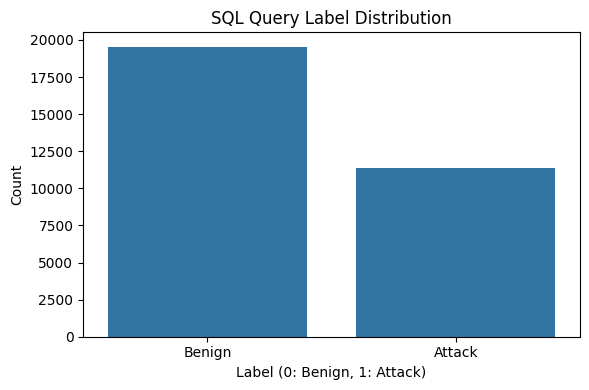

In [3]:
# Basic dataset checks

print("Dataset shape:")
print(df.shape)

print("\nDataset preview:")
display(df.head())

print("\nDataset info:")
df.info()

print("\nClass distribution:")
print(df['Label'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='Label', data=df)
plt.title('SQL Query Label Distribution')
plt.xlabel('Label (0: Benign, 1: Attack)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Benign', 'Attack'])
plt.tight_layout()
plt.show()


## 4. Data Cleaning


In [4]:
# Remove noisy benign UNION SELECT rows before model training

print(f"Rows before cleaning: {len(df)}")

mask = df['Sentence'].str.contains('UNION SELECT', case=False, na=False) & (df['Label'] == 0)
removed_noise = len(df[mask])
df = df[~mask].copy()

print(f"Removed {removed_noise} noisy rows (UNION SELECT as Benign).")
print(f"Rows after noise removal: {len(df)}")
print(df['Label'].value_counts())


Rows before cleaning: 30919
Removed 215 noisy rows (UNION SELECT as Benign).
Rows after noise removal: 30704
Label
0    19322
1    11382
Name: count, dtype: int64


## 5. Text Preprocessing


In [5]:
# Text preprocessing: URL decode, lowercase, remove noise, keep SQL symbols

def preprocess_text(text):
    text = unquote(text)
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s=\<\>\!\'"\(\)\[\]\{\}\-_\+\/\*\&\|\%\.\,\;\:\#\]]+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Processed_Sentence'] = df['Sentence'].apply(preprocess_text)

initial_count = len(df)
df.drop_duplicates(subset=['Processed_Sentence'], inplace=True)
print(f"Dropped {initial_count - len(df)} duplicate processed queries.")
print(f"Final dataset size: {len(df)}")


Dropped 191 duplicate processed queries.
Final dataset size: 30513


## 6. Train-Test Split and TF-IDF


In [6]:
# Stratified 80/20 split and character-level TF-IDF features

X = df['Processed_Sentence']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

tfidf_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    max_features=15000,
    sublinear_tf=True,
    min_df=2
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Features extracted: {X_train_tfidf.shape[1]}")
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print("\nTrain distribution:")
print(y_train.value_counts())
print("\nTest distribution:")
print(y_test.value_counts())


Features extracted: 15000
Train size: 24410 | Test size: 6103

Train distribution:
Label
0    15431
1     8979
Name: count, dtype: int64

Test distribution:
Label
0    3858
1    2245
Name: count, dtype: int64


## 7. Training Set Distribution


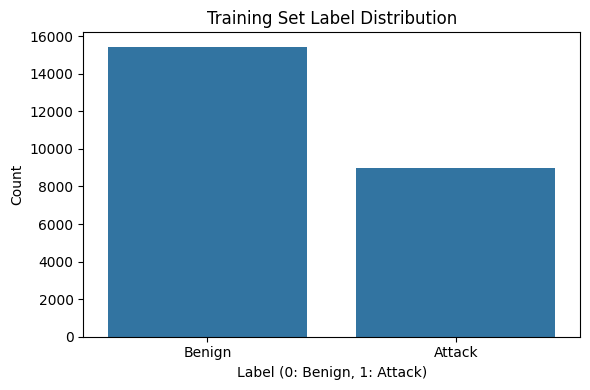

In [7]:
# Training label distribution

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title('Training Set Label Distribution')
plt.xlabel('Label (0: Benign, 1: Attack)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Benign', 'Attack'])
plt.tight_layout()
plt.show()


## 8. Train Random Forest


In [8]:
# Train Random Forest

print("Training Random Forest...")
start = time.time()

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_classifier.fit(X_train_tfidf, y_train)
print(f"Done in {time.time() - start:.2f}s")


Training Random Forest...
Done in 52.17s


## 9. Train XGBoost


In [9]:
# Train XGBoost with class imbalance weight

print("Training XGBoost...")
start = time.time()

pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"scale_pos_weight: {pos_weight:.4f}")

xgb_classifier = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_classifier.fit(X_train_tfidf, y_train)
print(f"Done in {time.time() - start:.2f}s")


Training XGBoost...
scale_pos_weight: 1.7186
Done in 90.58s


## 10. Train Hybrid Ensemble


In [10]:
# Soft-voting ensemble: averages RF and XGBoost probabilities

print("Training Hybrid Ensemble...")
start = time.time()

hybrid_model = VotingClassifier(
    estimators=[('rf', rf_classifier), ('xgb', xgb_classifier)],
    voting='soft',
    n_jobs=-1
)

hybrid_model.fit(X_train_tfidf, y_train)
print(f"Done in {time.time() - start:.2f}s")


Training Hybrid Ensemble...
Done in 126.03s


## 11. Evaluate All Models


In [11]:
# Evaluate RF, XGBoost, and Hybrid on test set

def get_metrics_values(model, X, y):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    return (
        accuracy_score(y, preds),
        precision_score(y, preds),
        recall_score(y, preds),
        f1_score(y, preds),
        roc_auc_score(y, probs)
    )

rf_accuracy, rf_precision, rf_recall, rf_f1, rf_auc = get_metrics_values(rf_classifier, X_test_tfidf, y_test)
xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_auc = get_metrics_values(xgb_classifier, X_test_tfidf, y_test)
hybrid_accuracy, hybrid_precision, hybrid_recall, hybrid_f1, hybrid_auc = get_metrics_values(hybrid_model, X_test_tfidf, y_test)

all_model_results = [
    {'Model': 'Random Forest', 'Accuracy': rf_accuracy, 'Precision': rf_precision, 'Recall': rf_recall, 'F1-score': rf_f1, 'ROC-AUC': rf_auc},
    {'Model': 'XGBoost', 'Accuracy': xgb_accuracy, 'Precision': xgb_precision, 'Recall': xgb_recall, 'F1-score': xgb_f1, 'ROC-AUC': xgb_auc},
    {'Model': 'Hybrid Ensemble', 'Accuracy': hybrid_accuracy, 'Precision': hybrid_precision, 'Recall': hybrid_recall, 'F1-score': hybrid_f1, 'ROC-AUC': hybrid_auc},
]

performance_df = pd.DataFrame(all_model_results).set_index('Model')
display(performance_df)


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Random Forest,0.997214,0.999104,0.993318,0.996203,0.999567
XGBoost,0.995576,0.997756,0.990200,0.993964,0.999403
Hybrid Ensemble,0.996559,0.999102,0.991537,0.995305,0.999628


## 12. Classification Report


In [12]:
# Classification report for the hybrid model

y_pred_hybrid = hybrid_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_hybrid, target_names=['Benign', 'Attack']))


              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      3858
      Attack       1.00      0.99      1.00      2245

    accuracy                           1.00      6103
   macro avg       1.00      1.00      1.00      6103
weighted avg       1.00      1.00      1.00      6103



## 13. Confusion Matrices


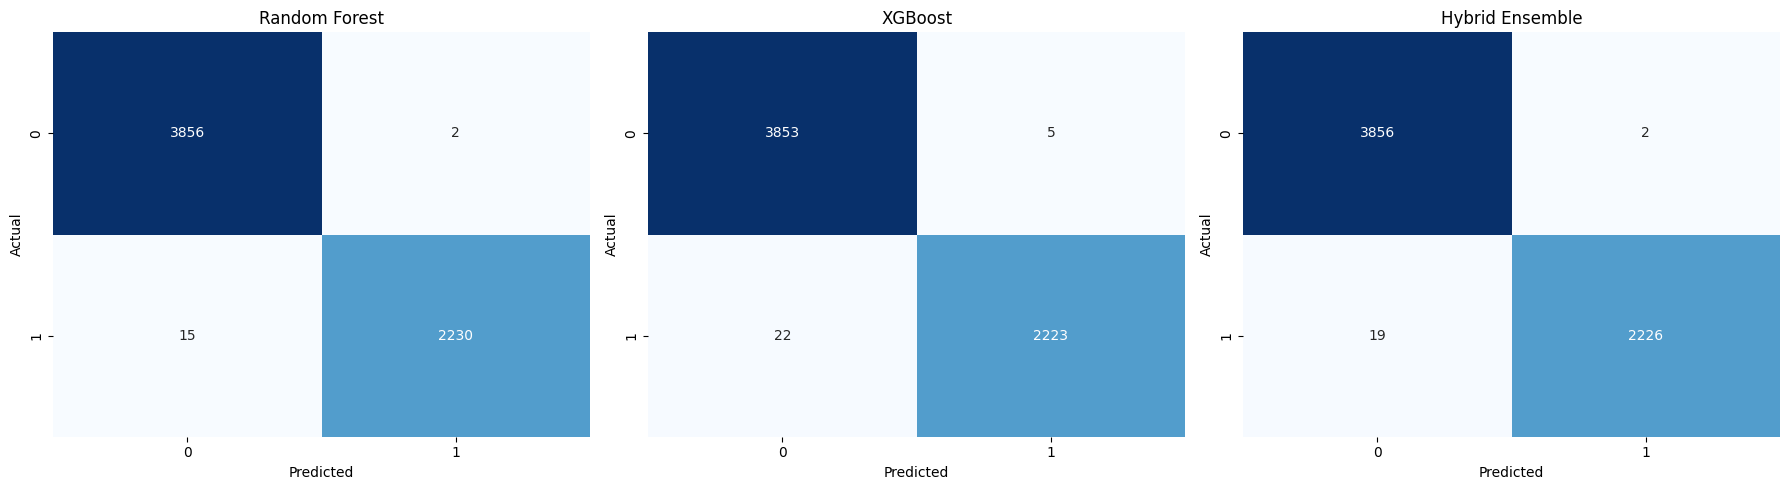

In [13]:
# Confusion matrices for all three models

models = [rf_classifier, xgb_classifier, hybrid_model]
names = ['Random Forest', 'XGBoost', 'Hybrid Ensemble']

plt.figure(figsize=(18, 5))
for i, (model, name) in enumerate(zip(models, names)):
    plt.subplot(1, 3, i + 1)
    cm = confusion_matrix(y_test, model.predict(X_test_tfidf))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(name)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 14. ROC Curves


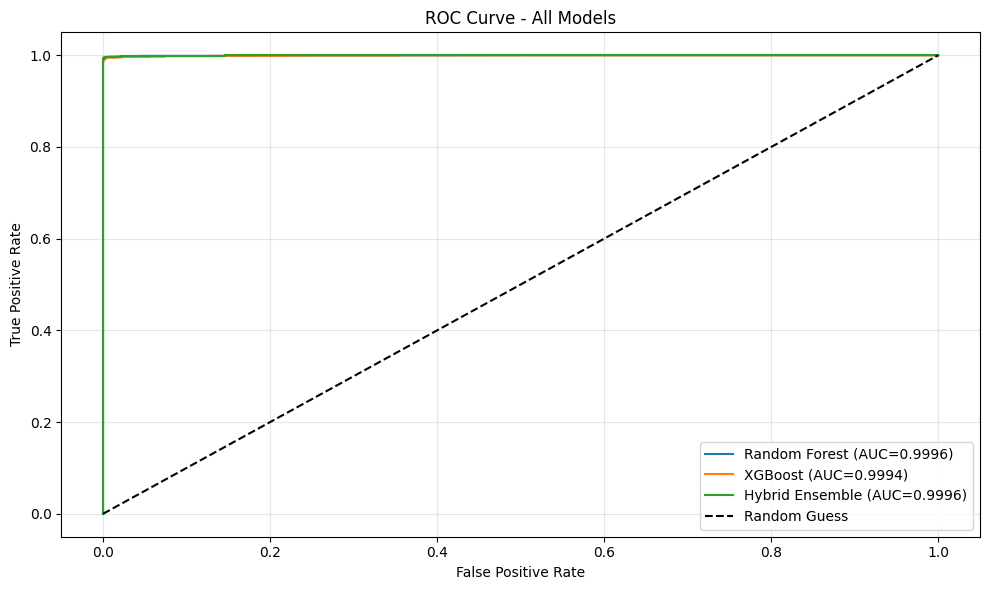

In [14]:
# ROC curves for all three models

plt.figure(figsize=(10, 6))
for model, name in zip(models, names):
    probs = model.predict_proba(X_test_tfidf)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, probs):.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Best Model Check


In [15]:
# Identify best model by F1 and ROC-AUC

best_model_f1 = performance_df['F1-score'].idxmax()
best_f1_score = performance_df['F1-score'].max()

best_model_roc_auc = performance_df['ROC-AUC'].idxmax()
best_roc_auc_score = performance_df['ROC-AUC'].max()

print(f"Best F1-score: {best_model_f1} ({best_f1_score:.4f})")
print(f"Best ROC-AUC: {best_model_roc_auc} ({best_roc_auc_score:.4f})")
print("Hybrid Ensemble is selected for deployment because it combines RF and XGBoost probability outputs through soft voting.")


Best F1-score: Random Forest (0.9962)
Best ROC-AUC: Hybrid Ensemble (0.9996)
Hybrid Ensemble is selected for deployment because it combines RF and XGBoost probability outputs through soft voting.


## 16. Feature Importance


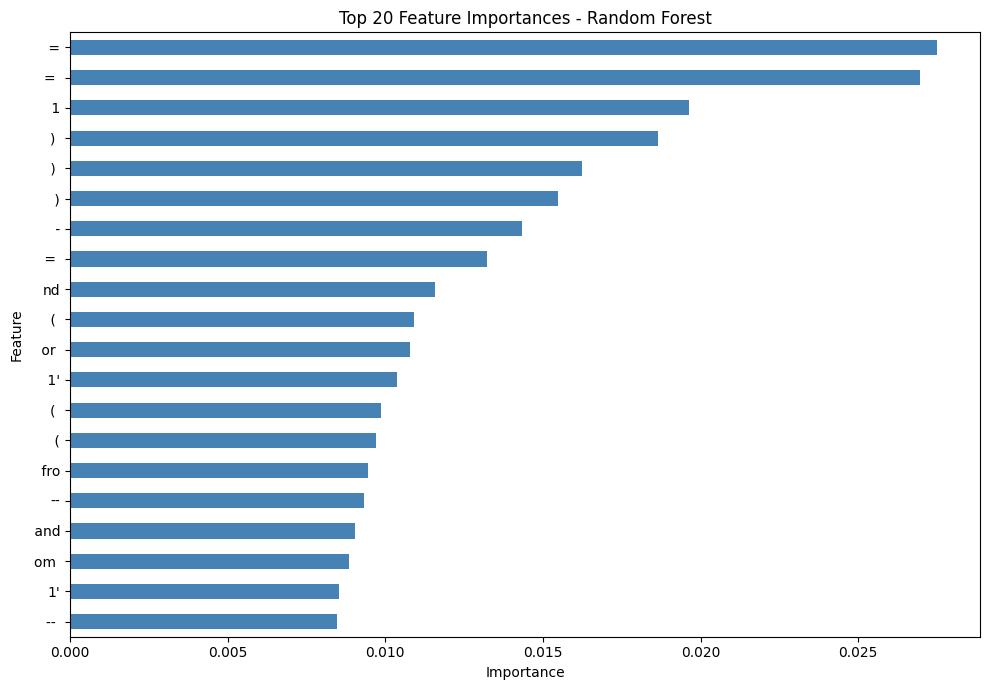

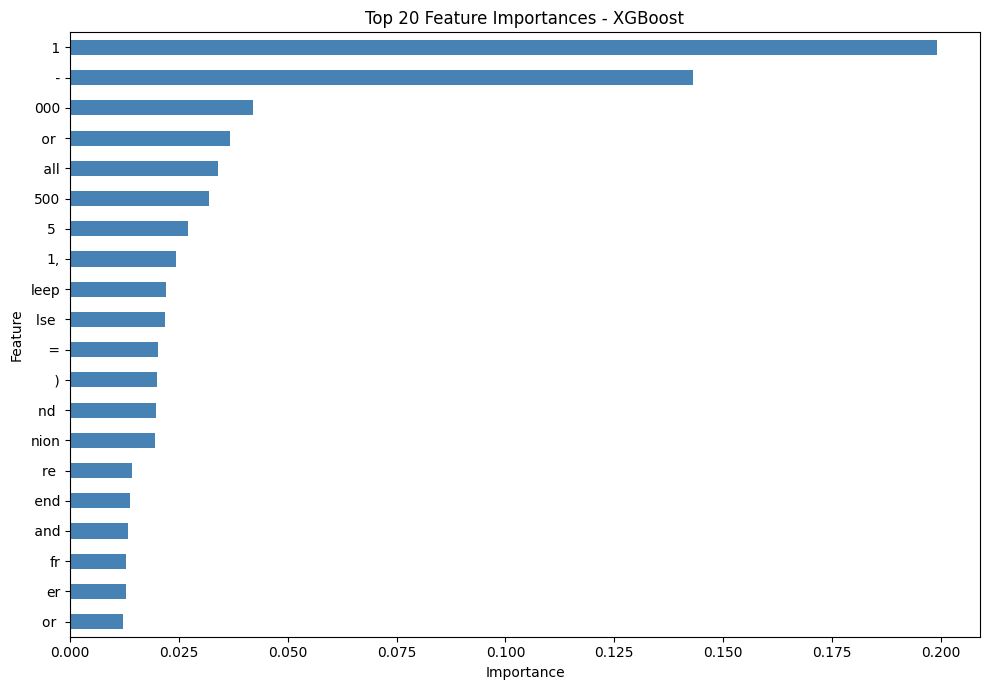

In [16]:
# Top 20 feature importances for RF and XGBoost

def plot_feature_importance(model, vectorizer, model_name, top_n=20):
    if not hasattr(model, 'feature_importances_'):
        print(f"{model_name} does not support feature_importances_")
        return

    feat_importances = pd.Series(
        model.feature_importances_,
        index=vectorizer.get_feature_names_out()
    )

    plt.figure(figsize=(10, 7))
    feat_importances.nlargest(top_n).sort_values().plot(kind='barh', color='steelblue')
    plt.title(f'Top {top_n} Feature Importances - {model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

plot_feature_importance(rf_classifier, tfidf_vectorizer, 'Random Forest')
plot_feature_importance(xgb_classifier, tfidf_vectorizer, 'XGBoost')


## 17. Error Analysis


In [17]:
# Misclassified samples from the test set

y_pred_hybrid = hybrid_model.predict(X_test_tfidf)
misclassified_indices = np.where(y_pred_hybrid != y_test)[0]

print(f"Total misclassifications: {len(misclassified_indices)}")

error_analysis = pd.DataFrame({
    'Query': X_test.iloc[misclassified_indices].values,
    'Actual': y_test.iloc[misclassified_indices].values,
    'Predicted': y_pred_hybrid[misclassified_indices]
})

display(error_analysis.head(10))


Total misclassifications: 21


,Query,Actual,Predicted
0,tz_offset,1,0
1,) union select * from information_schema.tables;,1,0
2,us,0,1
3,char39a+select,1,0
4,# from wapiti,1,0
5,insert,1,0
6,28%,1,0
7,create user name identified by pass123 tempora...,1,0
8,procedure,1,0
9,truncate,1,0


## 18. SQLi Pattern Interpretation


In [18]:
# Pattern-based interpretation helper for analyst output

def interpret_sqli_type(query):
    query = query.lower()
    attack_type = "Unknown/Generic SQLi"
    severity = "Medium"

    patterns = {
        'Authentication Bypass': [r'or\s+1\s*=\s*1', r'admin\'\s*--'],
        'Union-Based SQLi': [r'union\s+select', r'union\s+all\s+select'],
        'Time-Based Blind SQLi': [r'pg_sleep', r'waitfor\s+delay', r'benchmark\(', r'sleep\('],
        'Database Enumeration': [r'information_schema', r'syscolumns', r'sysobjects', r'table_name'],
        'Destructive Query': [r'drop\s+table', r'truncate\s+', r'delete\s+from', r'shutdown']
    }

    all_keywords = ['or', 'union', 'select', '1=1', '--', '/*', '*/', 'sleep', 'drop', 'insert', 'update', 'where', 'limit']
    detected_keywords = [kw for kw in all_keywords if kw in query]

    for category, regex_list in patterns.items():
        for regex in regex_list:
            if re.search(regex, query):
                attack_type = category
                severity = "Critical" if category == 'Destructive Query' else "High"
                break

    return attack_type, detected_keywords, severity


## 19. SHAP Setup


In [19]:
# SHAP explainer for the XGBoost model

shap.initjs()
feature_names = tfidf_vectorizer.get_feature_names_out()
explainer = shap.TreeExplainer(xgb_classifier)

X_test_array = X_test_tfidf[:500].toarray()
shap_values = explainer.shap_values(X_test_array)

shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test_array,
    feature_names=feature_names
)

print("SHAP explainer initialized.")


SHAP explainer initialized.


## 20. SHAP Summary Plot


/tmp/ipykernel_5276/535473746.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_array, feature_names=feature_names, show=False)


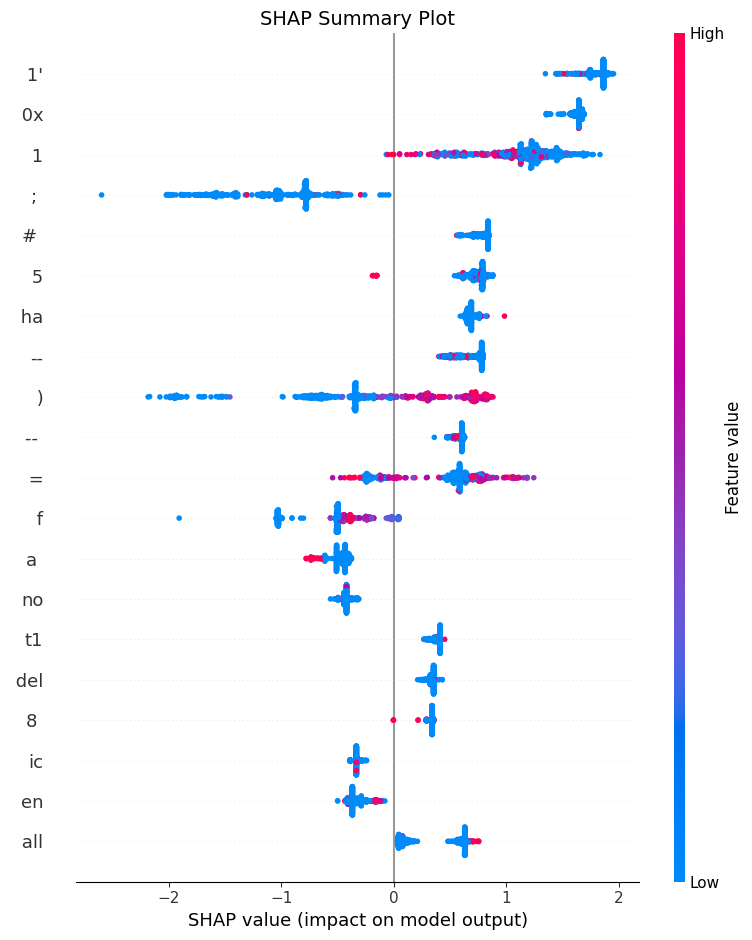

In [20]:
# Global feature impact

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_array, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot", fontsize=14)
plt.tight_layout()
plt.show()


## 21. SHAP Bar Plot


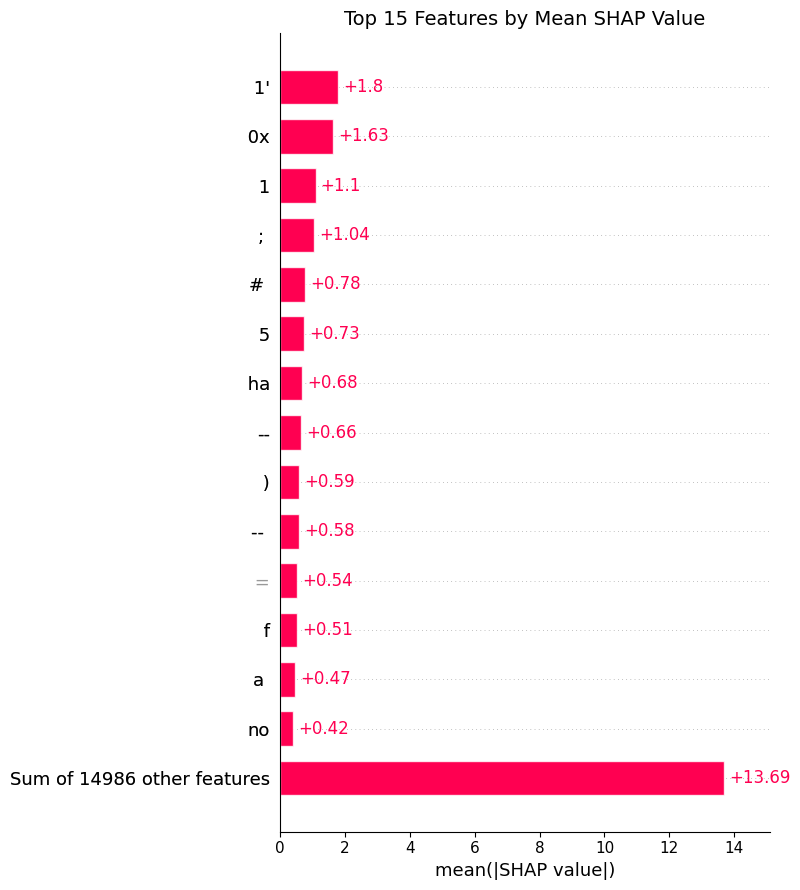

In [21]:
# Mean absolute SHAP values for top features

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_exp, max_display=15, show=False)
plt.title("Top 15 Features by Mean SHAP Value", fontsize=14)
plt.tight_layout()
plt.show()


## 22. SHAP Waterfall and Force Plot


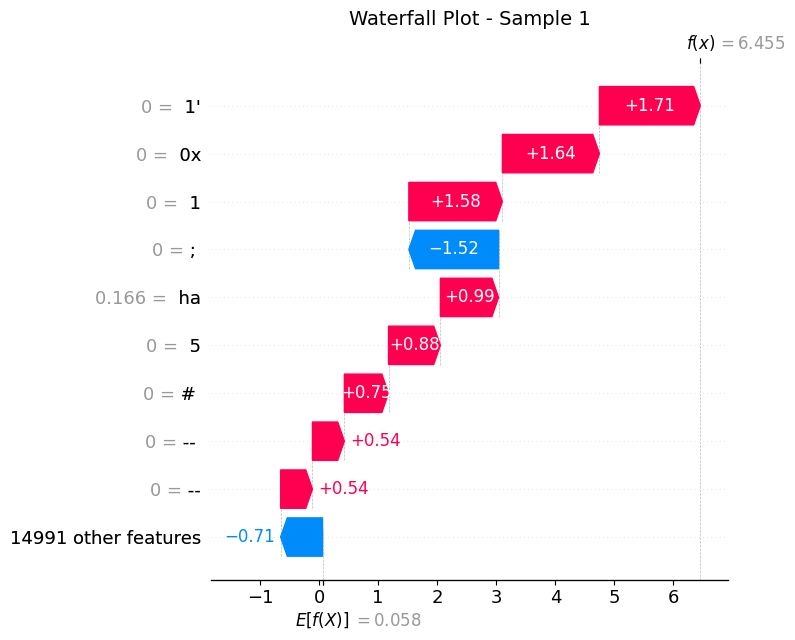

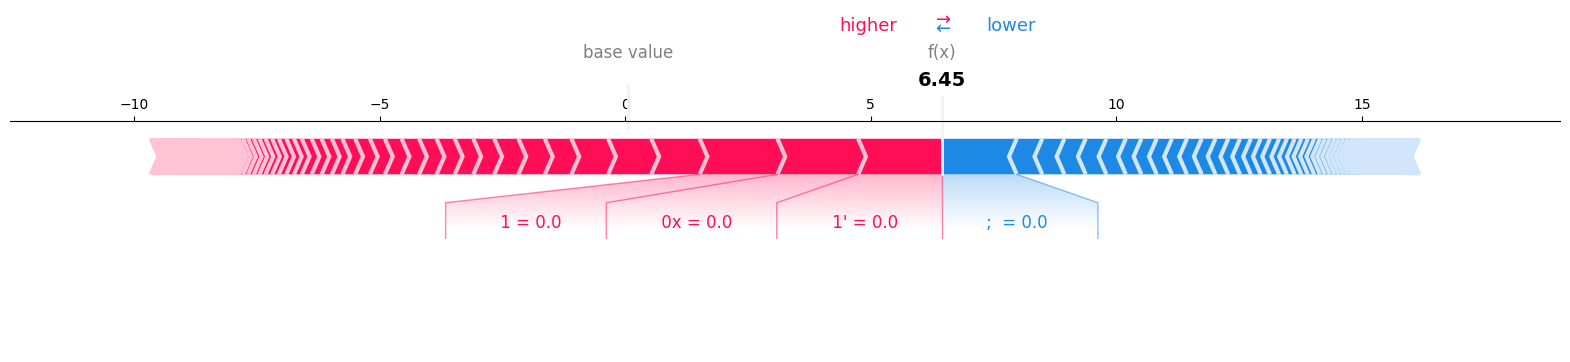

In [22]:
# Local explanation for a single sampled query

sample_idx = 1

plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_exp[sample_idx], max_display=10, show=False)
plt.title(f"Waterfall Plot - Sample {sample_idx}", fontsize=14)
plt.tight_layout()
plt.show()

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test_array[sample_idx],
    feature_names=feature_names,
    matplotlib=True
)


## 23. Live Query Tester


In [23]:
# Test a single query against the hybrid model

def test_query(raw_sql):
    clean_sql = preprocess_text(raw_sql)
    vec = tfidf_vectorizer.transform([clean_sql])
    pred = hybrid_model.predict(vec)[0]
    conf = np.max(hybrid_model.predict_proba(vec)) * 100

    attack_type, keywords, severity = interpret_sqli_type(clean_sql)
    risk = severity if pred == 1 else "Low"

    print("=" * 50)
    print(f"Query      : {raw_sql}")
    print(f"Status     : {'ATTACK' if pred == 1 else 'BENIGN'}")
    print(f"Confidence : {conf:.2f}%")
    print(f"Risk       : {risk}")
    print(f"Type       : {attack_type if pred == 1 else 'None'}")
    print(f"Keywords   : {', '.join(keywords) if keywords else 'None'}")
    print("=" * 50)

test_query("SELECT * FROM users WHERE id = '1' OR '1'='1' --")


Query      : SELECT * FROM users WHERE id = '1' OR '1'='1' --
Status     : ATTACK
Confidence : 83.00%
Risk       : Medium
Type       : Unknown/Generic SQLi
Keywords   : or, select, --, where


## 24. SOC Dashboard Simulation


In [24]:
# Batch query simulation with timestamps and risk levels

def soc_dashboard_simulation(queries):
    print(f"{'TIME':<10} | {'STATUS':<22} | {'RISK':<10} | QUERY")
    print("-" * 90)

    for q in queries:
        proc = preprocess_text(q)
        vec = tfidf_vectorizer.transform([proc])
        pred = hybrid_model.predict(vec)[0]
        proba = np.max(hybrid_model.predict_proba(vec))
        attack_type, _, severity = interpret_sqli_type(proc)

        ts = datetime.now().strftime('%H:%M:%S')
        status = "ATTACK" if pred == 1 else "CLEAN"
        risk = severity if pred == 1 else "NONE"
        summary = (q[:45] + '..') if len(q) > 45 else q

        print(f"{ts:<10} | {status:<10} ({proba*100:>5.2f}%) | {risk:<10} | {summary}")

sample_traffic = [
    "SELECT name, email FROM users WHERE id=5",
    "' OR '1'='1' --",
    "UNION SELECT NULL, table_name FROM information_schema.tables",
    "GET /api/v1/products?category=electronics",
    "1; DROP TABLE users; --"
]

soc_dashboard_simulation(sample_traffic)


TIME       | STATUS                 | RISK       | QUERY
------------------------------------------------------------------------------------------
16:41:18   | CLEAN      (87.18%) | NONE       | SELECT name, email FROM users WHERE id=5
16:41:19   | ATTACK     (98.25%) | Medium     | ' OR '1'='1' --
16:41:19   | CLEAN      (91.92%) | NONE       | UNION SELECT NULL, table_name FROM informatio..
16:41:19   | CLEAN      (98.41%) | NONE       | GET /api/v1/products?category=electronics
16:41:19   | ATTACK     (55.14%) | Critical   | 1; DROP TABLE users; --


## 25. Final Validation and Export


In [25]:
# Validation test cases and model export

sqli_patterns = [
    r"union\s+(all\s+)?select", r"or\s+1\s*=\s*1", r"sleep\s*\(",
    r"benchmark\s*\(", r"waitfor\s+delay", r"information_schema",
    r"drop\s+table", r"delete\s+from", r"/\*\*/", r"%20"
]

test_cases = [
    ("UNION SELECT username, password FROM users --", 1),
    ("' UNION SELECT null, table_name FROM information_schema.tables --", 1),
    ("1 UNION ALL SELECT 1,2,3,4,5 --", 1),
    ("' OR '1'='1' --", 1),
    ("admin'--", 1),
    ("' OR 1=1#", 1),
    ("1' AND SLEEP(5)--", 1),
    ("'; WAITFOR DELAY '0:0:5'--", 1),
    ("1 AND BENCHMARK(5000000, MD5(1))--", 1),
    ("'; DROP TABLE users;--", 1),
    ("1; DELETE FROM orders WHERE 1=1--", 1),
    ("1'/**/OR/**/1=1--", 1),
    ("UNION%20SELECT%20password%20FROM%20users", 1),
    ("' OR 'unusual'='unusual", 1),
    ("SELECT * FROM orders WHERE customer_id = 5", 0),
    ("SELECT name, email FROM customers WHERE status = 'active'", 0),
    ("UPDATE users SET last_login = NOW() WHERE id = 42", 0),
    ("INSERT INTO logs (event, ts) VALUES ('login', NOW())", 0),
]

print(f"{'EXPECTED':<12} {'ML PRED':<12} {'FINAL':<12} {'RESULT':<10} QUERY")
print("-" * 110)

passes = 0
for query, expected in test_cases:
    proc = preprocess_text(query)
    vec = tfidf_vectorizer.transform([proc])
    ml_pred = hybrid_model.predict(vec)[0]
    final_pred = ml_pred

    rule_flag = any(re.search(p, proc.lower()) for p in sqli_patterns)
    if rule_flag and final_pred == 0:
        final_pred = 1

    res = "PASS" if final_pred == expected else "FAIL"
    if res == "PASS":
        passes += 1

    print(f"{'ATTACK' if expected==1 else 'BENIGN':<12} {'ATTACK' if ml_pred==1 else 'BENIGN':<12} {'ATTACK' if final_pred==1 else 'BENIGN':<12} {res:<10} {query}")

print(f"\nFINAL VALIDATION PASS RATE: {passes}/{len(test_cases)} ({passes/len(test_cases)*100:.2f}%)")

joblib.dump(hybrid_model, 'hybrid_model.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(rf_classifier, 'rf_model.pkl')
joblib.dump(xgb_classifier, 'xgb_model.pkl')

print("\nModels saved: hybrid_model.pkl, tfidf_vectorizer.pkl, rf_model.pkl, xgb_model.pkl")


EXPECTED     ML PRED      FINAL        RESULT     QUERY
--------------------------------------------------------------------------------------------------------------
ATTACK       ATTACK       ATTACK       PASS       UNION SELECT username, password FROM users --
ATTACK       ATTACK       ATTACK       PASS       ' UNION SELECT null, table_name FROM information_schema.tables --
ATTACK       ATTACK       ATTACK       PASS       1 UNION ALL SELECT 1,2,3,4,5 --
ATTACK       ATTACK       ATTACK       PASS       ' OR '1'='1' --
ATTACK       ATTACK       ATTACK       PASS       admin'--
ATTACK       ATTACK       ATTACK       PASS       ' OR 1=1#
ATTACK       ATTACK       ATTACK       PASS       1' AND SLEEP(5)--
ATTACK       ATTACK       ATTACK       PASS       '; WAITFOR DELAY '0:0:5'--
ATTACK       BENIGN       ATTACK       PASS       1 AND BENCHMARK(5000000, MD5(1))--
ATTACK       ATTACK       ATTACK       PASS       '; DROP TABLE users;--
ATTACK       BENIGN       ATTACK       PASS       1